# Per-quantile one-sided CQR — constants + empirical validity

The exceedance-probability product claims ("90% chance this day settles in the
top 10% of the archive") need **each quantile head individually calibrated
one-sided** — the shipped symmetric band constant only guarantees the *joint*
90% band, and can park all of its miscoverage on one tail. This notebook
computes the six per-level shifts for **M3_base** (`qn8727_s0`, cache only —
nothing retrains) across **all four variables**, and measures how honest each
calibrated tail actually is on days the calibration never saw.

Setup choices, mirroring `make_debias_tables.py`:

- Data pipeline = `train_quantile_debias` (`preflight → load_and_verify →
  add_features → split → shrink`), **no archive refresh** — evaluate exactly
  what the fits saw.
- The trainer's `test` blocks are halved by **day parity**: odd days fit the
  shifts (calibration), even days measure validity (evaluation). Every test
  month lands in both halves and no day is shared, so the validity numbers are
  out-of-sample for both the fits *and* the shifts.
- Gated cells are **not** excluded — the shipped symmetric Q was computed
  across all cells too (`compute_cqr` runs before gating). A gate-filtered
  variant is a possible refinement.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from catboost import CatBoostRegressor

import train_quantile_debias as tqd

MODEL_TAG = "qn8727_s0"   # the shipped full-grid fits — loaded from cache, never retrained
CELL_LIMIT = None         # None = all 8727 cells; a small number = smoke run (constants not saved)

QUANTILE_LEVELS = tqd.QUANTILES                 # [.01, .05, .10, .50, .90, .95, .99]
SIDED_LEVELS = [q for q in QUANTILE_LEVELS if q != 0.50]
LEVEL_COLUMN = {level: i for i, level in enumerate(QUANTILE_LEVELS)}

# the source pipeline takes ~20 min; cache the shrunk frame (feather keeps the
# float32/category dtypes). Delete the file to rebuild after any data change
# (new hres pulls, cells.csv edits, archive refresh).
FRAME_CACHE = tqd.HERE / "data" / "pipeline_frame_full.feather"
if CELL_LIMIT is None and FRAME_CACHE.exists():
    data = pd.read_feather(FRAME_CACHE)
    tqd.log(f"loaded cached pipeline frame {FRAME_CACHE.name}: {len(data):,} rows"
            " (delete the file to rebuild from source)")
else:
    static_cells = tqd.preflight(CELL_LIMIT, allow_partial=False)
    data = tqd.load_and_verify(static_cells, allow_partial=False)
    data = tqd.add_features(data)
    data = tqd.split(data)
    data = tqd.shrink(data).reset_index(drop=True)   # feather needs a default index
    if CELL_LIMIT is None:
        data.to_feather(FRAME_CACHE)
        tqd.log(f"cached pipeline frame -> {FRAME_CACHE}")

test_rows = data[data.role == "test"]
calibration_rows = test_rows[test_rows.date.dt.day % 2 == 1]  # odd days fit the shifts
evaluation_rows = test_rows[test_rows.date.dt.day % 2 == 0]   # even days measure honesty
print(f"test rows: {len(test_rows):,} -> calibration {len(calibration_rows):,}"
      f" / evaluation {len(evaluation_rows):,}")


[09:37:59] loaded cached pipeline frame pipeline_frame_full.feather: 7,179,885 rows (delete the file to rebuild from source)


test rows: 1,597,041 -> calibration 811,611 / evaluation 785,430


## The recipe

For each level τ ∈ {.01, .05, .10, .90, .95, .99}, on the calibration half:
residuals `y − q̂τ`, then the shift `cτ` is their finite-sample empirical
τ-quantile — rank **⌈(n+1)τ⌉ rounded up** for upper levels (coverage ≥ τ),
**⌊(n+1)τ⌋ rounded down** for lower levels (tail below stays ≤ τ). This is
`conformal_q` generalized per level.

Two differences from the shipped band constant to keep in mind:

- Shifts are **signed**, not widenings — a negative `c95` pulls in a q95 head
  that was over-shooting. No clipping at zero.
- `q50` stays untouched (the point value ships CQR-free by design), and the 90%
  band becomes `[q05+c05, q95+c95]` — covered ≥ 90% by union bound, so expect
  it slightly *wider* than today's symmetric band. The part-10 symmetric Q is
  recomputed on the same calibration half as a reference column.

After shifting, per-row monotonicity can break again (six different constants),
so the future bake step must re-sort; the crossing fraction below says how much
that matters.


In [2]:
def per_level_shift(residuals: np.ndarray, level: float) -> float:
    """One-sided split-conformal shift c so that P(y <= q_hat + c) ~= level.

    conformal_q generalized per level: upper levels round the finite-sample
    rank UP (coverage >= level), lower levels round DOWN (tail below stays
    <= level). Residuals are y - q_hat, so shifts are SIGNED — never clip.
    """
    ordered = np.sort(residuals)
    n = len(ordered)
    if level > 0.5:
        rank = min(int(np.ceil((n + 1) * level)), n)
    else:
        rank = max(int(np.floor((n + 1) * level)), 1)
    return float(ordered[rank - 1])


# forecast-extremeness bins for conditional coverage: percentile of the day's
# forecast WITHIN ITS CELL's training forecast distribution (a 30° forecast is
# extreme in Oslo, mundane in Delhi — raw values must not be pooled)
FORECAST_BIN_EDGES = [0, 0.01, 0.05, 0.25, 0.75, 0.95, 0.99, 1]
FORECAST_BIN_LABELS = ["bottom 1%", "1–5%", "5–25%", "25–75%",
                       "75–95%", "95–99%", "top 1%"]

shift_rows, coverage_rows, monthly_tail_rows = [], [], []
crossing_rows, conditional_rows = [], []

for var in tqd.VARS:
    name = var["name"]
    features = tqd.feature_cols(name, with_cell=True, with_cross=False)
    model = CatBoostRegressor()
    model.load_model(str(tqd.MODELS / f"M3_base_{name}_{MODEL_TAG}.cbm"))

    calibration = calibration_rows[calibration_rows[f"bias_{name}"].notna()]
    evaluation = evaluation_rows[evaluation_rows[f"bias_{name}"].notna()]
    # rows sorted ascending per prediction (the pipeline's crossing fix);
    # sorted column i is treated as QUANTILE_LEVELS[i] throughout
    calibration_preds = np.sort(np.asarray(model.predict(calibration[features])), axis=1)
    evaluation_preds = np.sort(np.asarray(model.predict(evaluation[features])), axis=1)
    calibration_y = calibration[f"bias_{name}"].to_numpy()
    evaluation_y = evaluation[f"bias_{name}"].to_numpy()
    evaluation_month = evaluation.date.dt.to_period("M").astype(str).to_numpy()

    # each evaluation day's forecast percentile within its cell (vs training)
    hres_column = tqd.hres_col(name)
    train_forecasts = data[(data.role == "train") & data[f"bias_{name}"].notna()]
    sorted_train = {key: np.sort(values.to_numpy()) for key, values
                    in train_forecasts.groupby("key", observed=True)[hres_column]}
    evaluation_forecast = evaluation[hres_column].to_numpy()
    forecast_pct = np.full(len(evaluation), np.nan)
    for key, positions in evaluation.groupby("key", observed=True).indices.items():
        reference = sorted_train.get(key)
        if reference is not None and len(reference):
            forecast_pct[positions] = (np.searchsorted(
                reference, evaluation_forecast[positions], side="right")
                / len(reference))
    forecast_bin = pd.cut(forecast_pct, FORECAST_BIN_EDGES,
                          labels=FORECAST_BIN_LABELS, include_lowest=True)

    shifts = {}
    for level in SIDED_LEVELS:
        head = calibration_preds[:, LEVEL_COLUMN[level]]
        shifts[level] = per_level_shift(calibration_y - head, level)

    # part-10 symmetric band constant on the same calibration half, for reference
    symmetric_scores = np.maximum(
        calibration_preds[:, LEVEL_COLUMN[0.05]] - calibration_y,
        calibration_y - calibration_preds[:, LEVEL_COLUMN[0.95]])
    rank = min(int(np.ceil((len(symmetric_scores) + 1) * 0.90)), len(symmetric_scores))
    symmetric_q90 = float(np.sort(symmetric_scores)[rank - 1])

    shift_rows += [{"var": name, "level": level, "shift": shifts[level]}
                   for level in SIDED_LEVELS]
    shift_rows.append({"var": name, "level": "symmetric_Q90_ref",
                       "shift": symmetric_q90})

    for level in QUANTILE_LEVELS:
        head = evaluation_preds[:, LEVEL_COLUMN[level]]
        coverage_rows.append({"var": name, "level": level, "stage": "raw",
                              "empirical_cdf": float(np.mean(evaluation_y <= head))})
        if level == 0.50:
            continue                  # the point value ships uncalibrated by design
        calibrated_head = head + shifts[level]
        coverage_rows.append({"var": name, "level": level, "stage": "calibrated",
                              "empirical_cdf": float(np.mean(evaluation_y <= calibrated_head))})
        in_tail = (evaluation_y <= calibrated_head if level < 0.5
                   else evaluation_y > calibrated_head)
        by_month = pd.Series(in_tail).groupby(evaluation_month).mean()
        monthly_tail_rows += [{"var": name, "level": level, "month": month,
                               "tail_mass": mass} for month, mass in by_month.items()]
        by_bin = pd.Series(in_tail).groupby(forecast_bin, observed=False).agg(
            ["mean", "size"])
        conditional_rows += [{"var": name, "level": level, "bin": str(bin_label),
                              "tail_mass": row["mean"], "n": int(row["size"])}
                             for bin_label, row in by_bin.iterrows()]

    corrected = evaluation_preds.copy()
    for level in SIDED_LEVELS:
        corrected[:, LEVEL_COLUMN[level]] += shifts[level]
    crossing_rows.append({"var": name, "crossing_fraction": float(
        np.mean(np.any(np.diff(corrected, axis=1) < 0, axis=1)))})
    tqd.log(f"{name}: " + " ".join(f"c{int(level * 100):02d}={shifts[level]:+.3f}"
                                   for level in SIDED_LEVELS)
            + f" | symmetric Q90 ref {symmetric_q90:.3f}")

shifts_long = pd.DataFrame(shift_rows)
coverage = pd.DataFrame(coverage_rows)
monthly_tails = pd.DataFrame(monthly_tail_rows)
crossings = pd.DataFrame(crossing_rows).set_index("var")
conditional = pd.DataFrame(conditional_rows)
VAR_NAMES = [v["name"] for v in tqd.VARS]

if CELL_LIMIT is None:
    shifts_csv = tqd.MODELS / f"per_level_cqr_{MODEL_TAG}.csv"
    shifts_long[shifts_long.level != "symmetric_Q90_ref"].to_csv(shifts_csv, index=False)
    print(f"saved {shifts_csv}")
else:
    print("CELL_LIMIT set -> smoke run, constants NOT saved")

shifts_table = (shifts_long.pivot(index="var", columns="level", values="shift")
                .reindex(index=VAR_NAMES,
                         columns=SIDED_LEVELS + ["symmetric_Q90_ref"]))
calibrated_cdf_pct = (coverage[coverage.stage == "calibrated"]
                      .pivot(index="var", columns="level", values="empirical_cdf")
                      .reindex(index=VAR_NAMES) * 100)
display(shifts_table.round(3))
display(calibrated_cdf_pct.round(2))
display(crossings.round(4))


[09:38:10] tmax: c01=-0.074 c05=-0.043 c10=-0.034 c90=+0.057 c95=+0.091 c99=+0.208 | symmetric Q90 ref 0.067


[09:38:16] tmin: c01=-0.123 c05=-0.072 c10=-0.053 c90=+0.044 c95=+0.061 c99=+0.104 | symmetric Q90 ref 0.066


[09:38:20] precip: c01=+0.000 c05=-0.000 c10=-0.000 c90=-0.000 c95=-0.003 c99=-0.006 | symmetric Q90 ref 0.000


[09:38:26] wind: c01=-0.016 c05=-0.012 c10=-0.009 c90=+0.013 c95=+0.019 c99=+0.053 | symmetric Q90 ref 0.015


saved /home/ita/HowHotWasIt/scripts/bias_study/models/per_level_cqr_qn8727_s0.csv


level,0.01,0.05,0.1,0.9,0.95,0.99,symmetric_Q90_ref
var,,,,,,,
tmax,-0.074,-0.043,-0.034,0.057,0.091,0.208,0.067
tmin,-0.123,-0.072,-0.053,0.044,0.061,0.104,0.066
precip,0.000,-0.000,-0.000,-0.000,-0.003,-0.006,0.000
wind,-0.016,-0.012,-0.009,0.013,0.019,0.053,0.015


level,0.01,0.05,0.10,0.90,0.95,0.99
var,,,,,,
tmax,1.00,4.99,9.95,90.03,95.07,99.08
tmin,1.00,5.08,10.12,90.35,95.23,99.09
precip,1.00,4.87,9.73,89.94,95.00,98.99
wind,1.03,5.00,9.96,90.20,95.16,99.05


,crossing_fraction
var,
tmax,0.0000
tmin,0.0000
precip,0.1794
wind,0.0000


## Reading the tables

- `shifts_table`: how far off each raw head is, in the variable's own units.
  Near-zero `c05`–`c10`/`c90`–`c95` with large `c01`/`c99` = the interior CDF is
  trustworthy and only the extreme rungs of the claim ladder need caution.
- `symmetric_Q90_ref` is today's band recipe on the same calibration data — the
  per-level `c05`/`c95` replace it (as *shifts*, one per side).
- `crossings`: fraction of evaluation rows whose 7 corrected quantiles are no
  longer monotone. Should be ~0; whatever remains, the bake re-sort absorbs.
- `calibrated_cdf_pct`: empirical CDF at each calibrated head on the evaluation
  half — the direct "is 0.05 really 0.05" check, in percent.


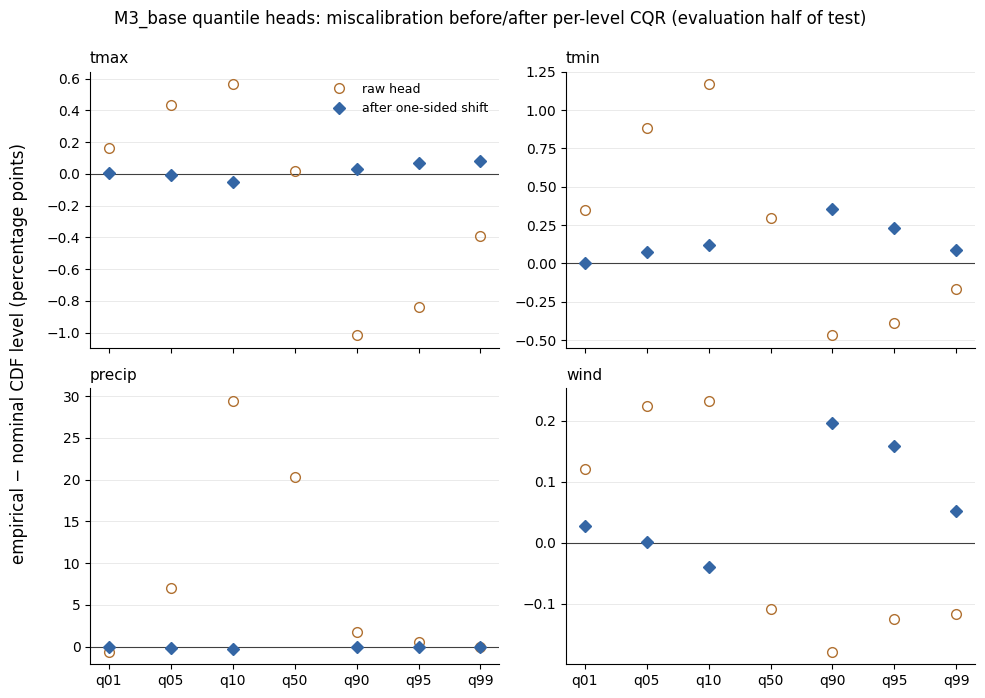

In [3]:
RAW_COLOR = "#B07030"         # uncorrected heads
CALIBRATED_COLOR = "#3466A5"  # after the one-sided shifts

# sharey=False: precip's raw dry-day atom (+30pp) must not squash the
# temperature panels onto the zero line
fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True)
x_all = np.arange(len(QUANTILE_LEVELS))
x_labels = [f"q{int(level * 100):02d}" for level in QUANTILE_LEVELS]
for ax, name in zip(axes.flat, VAR_NAMES):
    per_var = coverage[coverage["var"] == name]
    raw_cdf = per_var[per_var.stage == "raw"].set_index("level").empirical_cdf
    cal_cdf = per_var[per_var.stage == "calibrated"].set_index("level").empirical_cdf
    ax.axhline(0, color="0.25", lw=0.8)
    ax.plot(x_all, [(raw_cdf[level] - level) * 100 for level in QUANTILE_LEVELS],
            "o", mfc="none", color=RAW_COLOR, ms=7, ls="", label="raw head")
    ax.plot([LEVEL_COLUMN[level] for level in SIDED_LEVELS],
            [(cal_cdf[level] - level) * 100 for level in SIDED_LEVELS],
            "D", color=CALIBRATED_COLOR, ms=6, ls="", label="after one-sided shift")
    ax.set_title(name, loc="left", fontsize=11)
    ax.set_xticks(x_all, x_labels)
    ax.grid(axis="y", color="0.9", lw=0.6)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
fig.supylabel("empirical − nominal CDF level (percentage points)")
axes[0, 0].legend(frameon=False, fontsize=9)
fig.suptitle("M3_base quantile heads: miscalibration before/after per-level CQR"
             " (evaluation half of test)", y=0.99)
fig.tight_layout()
plt.show()


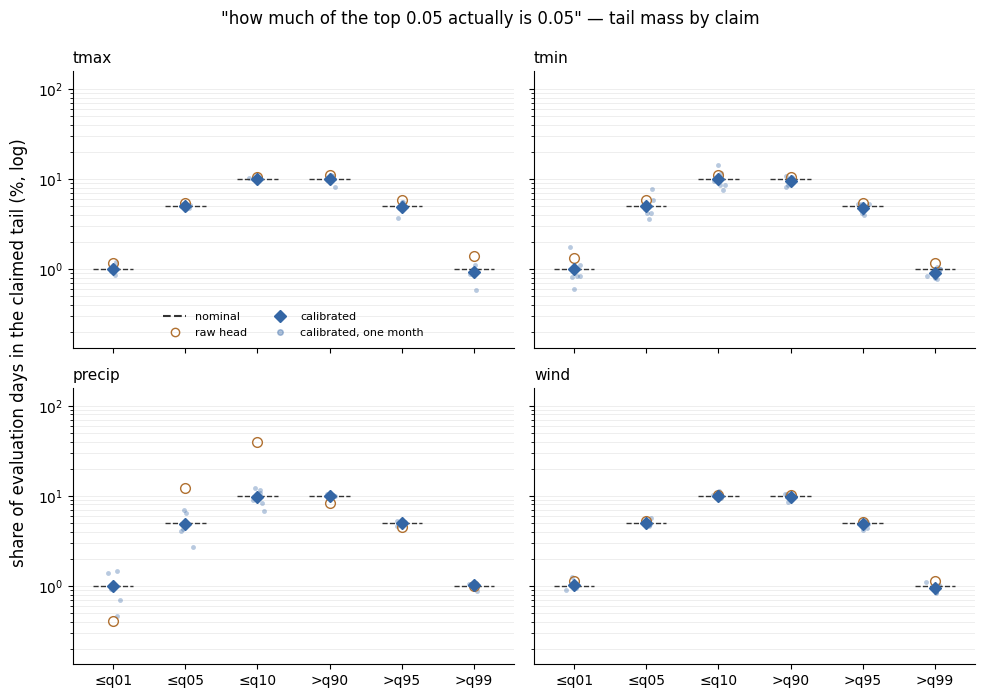

In [4]:
from matplotlib.lines import Line2D

CLAIMS = [(0.01, "≤q01"), (0.05, "≤q05"), (0.10, "≤q10"),
          (0.90, ">q90"), (0.95, ">q95"), (0.99, ">q99")]
nominal_pct = [level * 100 if level < 0.5 else (1 - level) * 100
               for level, _ in CLAIMS]

jitter_rng = np.random.default_rng(0)
zero_months = 0
plotted_pct = []          # every positive plotted value -> data-driven y-limits
fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True, sharey=True)
for ax, name in zip(axes.flat, VAR_NAMES):
    per_var = coverage[coverage["var"] == name].set_index(["stage", "level"]).empirical_cdf
    for i, (level, _) in enumerate(CLAIMS):
        months = monthly_tails[(monthly_tails["var"] == name)
                               & (monthly_tails.level == level)].tail_mass.to_numpy()
        zero_months += int((months == 0).sum())
        month_pct = np.where(months > 0, months, np.nan) * 100
        plotted_pct += [m for m in month_pct if np.isfinite(m)]
        ax.plot(i + jitter_rng.normal(0, 0.05, len(months)), month_pct,
                "o", color=CALIBRATED_COLOR, ms=3.5, alpha=0.35, mec="none")
        ax.hlines(nominal_pct[i], i - 0.28, i + 0.28, color="0.2", lw=1, ls="--")
        for stage, marker, color, fill in (("raw", "o", RAW_COLOR, "none"),
                                           ("calibrated", "D", CALIBRATED_COLOR, None)):
            cdf = per_var.loc[(stage, level)]
            tail = cdf if level < 0.5 else 1 - cdf
            if tail < 1e-9:           # float dust from 1 - cdf, or a truly empty tail
                continue
            plotted_pct.append(tail * 100)
            ax.plot(i, tail * 100, marker, ms=7 if stage == "raw" else 6,
                    color=color, mfc=fill)
    ax.set_yscale("log")
    ax.set_title(name, loc="left", fontsize=11)
    ax.set_xticks(range(len(CLAIMS)), [claim for _, claim in CLAIMS])
    ax.grid(axis="y", color="0.92", lw=0.6, which="both")
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
axes[0, 0].set_ylim(min(plotted_pct) / 3, max(plotted_pct) * 4)   # sharey spreads it
fig.supylabel("share of evaluation days in the claimed tail (%, log)")
axes[0, 0].legend(handles=[
    Line2D([], [], ls="--", color="0.2", label="nominal"),
    Line2D([], [], marker="o", mfc="none", color=RAW_COLOR, ls="", label="raw head"),
    Line2D([], [], marker="D", color=CALIBRATED_COLOR, ls="", label="calibrated"),
    Line2D([], [], marker="o", color=CALIBRATED_COLOR, ls="", ms=4, alpha=0.4,
           label="calibrated, one month")],
    frameon=False, fontsize=8, loc="lower center", ncol=2)
fig.suptitle('"how much of the top 0.05 actually is 0.05" — tail mass by claim',
             y=0.99)
fig.tight_layout()
plt.show()
if zero_months:
    print(f"note: {zero_months} (var, level, month) tail masses were exactly 0"
          " -> dropped from the log plot")


## Conditional coverage — does an extreme forecast stay calibrated?

The conformal guarantee above is **marginal**: averaged over all evaluation
days. But the product claims fire precisely on the non-average days — a
"hottest 1%" banner appears when the forecast itself is extreme. Nothing
guarantees the global shifts hold there; that's an empirical question, answered
here by slicing the same evaluation days by **forecast extremeness**:

- Each day's forecast is ranked within its own cell's *training* forecast
  distribution (~2 years of days), giving a within-cell percentile — so
  "extreme" means extreme for that place, not globally.
- Days are binned by that percentile; per bin × claim, the tail mass at the
  *same global calibrated heads* is measured. `conditional_ratio` shows
  empirical/nominal (1.00 = perfectly honest; 2 = the claim fires twice as
  often as advertised in that regime).
- The figure condenses to three regimes: bottom 5%, middle 50%, top 5% of
  forecasts. The money cells are the **top-5% regime × upper claims** — that's
  the exact population "this is one of the hottest days" is shown to.

If the extreme regimes drift badly, the remedy is already scored in part 10:
per-forecast-decile CQR (bin-conditional constants) instead of one global
shift per level. Precip note: the dry atom means no cell has forecasts below
its ~60th training percentile, so precip's lower bins are empty by
construction — judge precip in the top bins only.


bin           bottom 1%  1–5%  5–25%  25–75%  75–95%  95–99%  top 1%
var    level                                                        
tmax   0.01        1.56  2.15   0.93    0.98    0.85    1.05    1.20
       0.05        1.11  1.64   0.94    0.99    0.93    1.11    1.04
       0.10        1.07  1.37   0.95    0.99    0.95    1.06    1.02
       0.90        1.20  1.03   1.00    0.94    1.05    1.17    1.15
       0.95        1.32  1.10   0.97    0.90    1.07    1.29    1.14
       0.99        1.83  1.26   0.87    0.82    0.95    1.40    1.18
tmin   0.01        1.38  1.12   1.07    1.00    0.82    1.05    1.42
       0.05        0.89  0.93   1.07    1.02    0.97    0.98    1.12
       0.10        0.84  0.90   1.04    1.02    0.98    1.01    1.06
       0.90        1.50  1.18   1.00    0.88    1.00    1.06    1.12
       0.95        1.58  1.28   1.00    0.86    0.98    1.04    1.11
       0.99        1.94  1.43   0.94    0.80    0.92    0.98    1.47
precip 0.01         NaN  0.00   0.29    0.70    1.24    1.57    0.58
       0.05         NaN  0.34   0.49    0.60    1.22    1.39    2.04
       0.10         NaN  0.52   1.03    0.72    1.16    1.29    1.24
       0.90         NaN  2.93   1.14    1.00    1.02    0.97    0.94
       0.95         NaN  3.45   1.19    0.95    1.03    1.06    1.04
       0.99         NaN  8.62   1.31    0.97    1.09    0.98    0.50
wind   0.01        1.33  1.19   1.07    0.98    1.00    1.13    1.87
       0.05        0.84  1.03   1.04    0.98    0.98    1.02    1.47
       0.10        0.84  0.99   1.03    0.98    0.98    1.03    1.38
       0.90        1.29  1.07   0.93    0.98    0.99    0.99    0.87
       0.95        1.37  1.06   0.91    0.96    1.00    0.99    0.80
       0.99        1.47  1.25   0.82    0.92    1.05    0.88    0.85

smallest bin: n=0 — at the 1% claims a bin needs a few thousand rows before the ratio outruns binomial noise


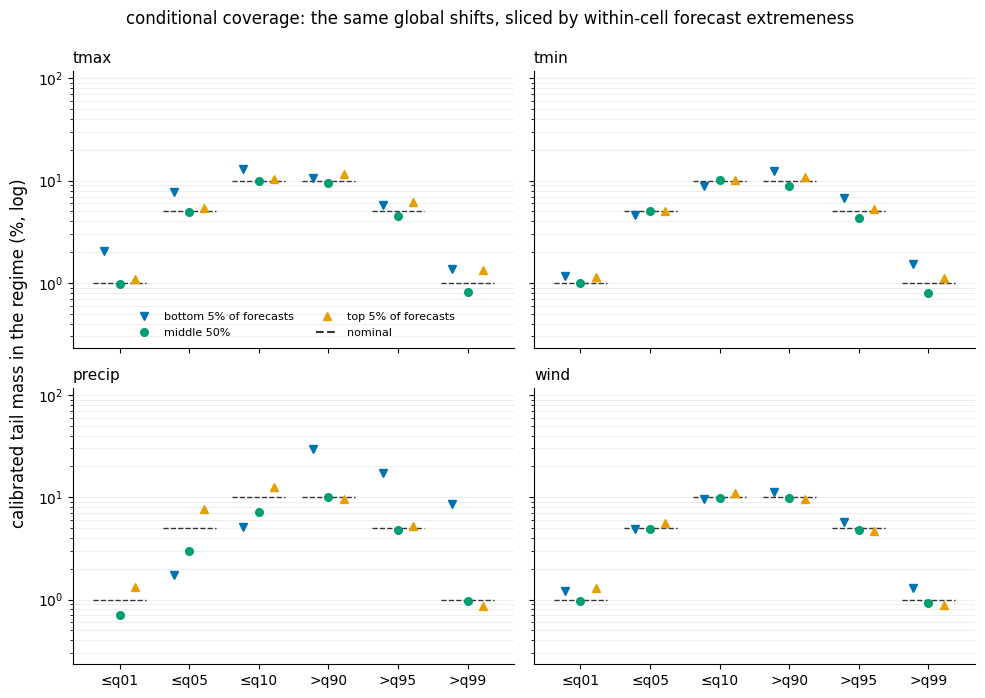

In [5]:
CLAIMS = [(0.01, "≤q01"), (0.05, "≤q05"), (0.10, "≤q10"),
          (0.90, ">q90"), (0.95, ">q95"), (0.99, ">q99")]
nominal_pct = [level * 100 if level < 0.5 else (1 - level) * 100
               for level, _ in CLAIMS]

# empirical/nominal ratio per fine bin (1.00 = honest), the full detail table
conditional["ratio"] = conditional.tail_mass / [
    level if level < 0.5 else round(1 - level, 6) for level in conditional.level]
conditional_ratio = (conditional.pivot_table(index=["var", "level"], columns="bin",
                                             values="ratio", observed=False)
                     .reindex(index=VAR_NAMES, level=0)
                     .reindex(columns=FORECAST_BIN_LABELS))
display(conditional_ratio.round(2))
print(f"smallest bin: n={conditional.n.min():,} — at the 1% claims a bin needs"
      " a few thousand rows before the ratio outruns binomial noise")

# condensed to three regimes; the money cells are top-5% x upper claims
REGIMES = [("bottom 5% of forecasts", ["bottom 1%", "1–5%"], "#0072B2", "v"),
           ("middle 50%", ["25–75%"], "#009E73", "o"),
           ("top 5% of forecasts", ["95–99%", "top 1%"], "#E69F00", "^")]

plotted_pct = []
fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True, sharey=True)
for ax, name in zip(axes.flat, VAR_NAMES):
    for i, (level, _) in enumerate(CLAIMS):
        ax.hlines(nominal_pct[i], i - 0.38, i + 0.38, color="0.2", lw=1, ls="--")
        for offset, (regime, bins, color, marker) in zip((-0.22, 0, 0.22), REGIMES):
            sub = conditional[(conditional["var"] == name)
                              & (conditional.level == level)
                              & conditional.bin.isin(bins)].dropna(subset=["tail_mass"])
            if not sub.n.sum():
                continue
            mass_pct = (sub.tail_mass * sub.n).sum() / sub.n.sum() * 100
            if mass_pct <= 0:
                continue
            plotted_pct.append(mass_pct)
            ax.plot(i + offset, mass_pct, marker, color=color, ms=5.5)
    ax.set_yscale("log")
    ax.set_title(name, loc="left", fontsize=11)
    ax.set_xticks(range(len(CLAIMS)), [claim for _, claim in CLAIMS])
    ax.grid(axis="y", color="0.92", lw=0.6, which="both")
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
axes[0, 0].set_ylim(min(plotted_pct) / 3, max(plotted_pct) * 4)
fig.supylabel("calibrated tail mass in the regime (%, log)")
from matplotlib.lines import Line2D
axes[0, 0].legend(handles=[
    Line2D([], [], marker=marker, color=color, ls="", ms=5.5, label=regime)
    for regime, _, color, marker in REGIMES]
    + [Line2D([], [], ls="--", color="0.2", label="nominal")],
    frameon=False, fontsize=8, loc="lower center", ncol=2)
fig.suptitle("conditional coverage: the same global shifts, sliced by"
             " within-cell forecast extremeness", y=0.99)
fig.tight_layout()
plt.show()


## Caveats / what to look for

- **Precip lower tails are near-meaningless**: the bias distribution has an
  atom where forecast and archive are both dry, so `≤q01/≤q05/≤q10` coverage is
  tie-dominated (we count `≤`, atoms can overshoot the nominal mass). The
  product claim for precip is the wet **upper** tail; judge precip there.
- **The monthly dots are the real story for the tails.** The aggregate
  calibrated marker sits on nominal by construction (that's the conformal
  guarantee, marginal over everything); the spread of the per-month dots is the
  conditional miscoverage a single global shift cannot fix — expect it wider at
  q99 than at q90. Wide dots at the extreme levels ⇒ use fuzzy wording bins
  ("virtually certain", "likely") on those rungs, not precise probabilities.
- If this looks good, the bake change in `make_debias_tables.py` is: ship all 7
  delta columns (not `dlo/dmid/dhi`), add each level's shift, **re-sort per
  row**, and the client interpolates the 7-point CDF — clamping beyond
  q01/q99 to "<1%"/">99%".
- Shifts land in `models/per_level_cqr_qn8727_s0.csv` (full runs only).


## Gated cells: empirical per-cell CQR

Everything above is the **M3_base model** CQR, across all 8727 cells. But
`make_debias_tables.py` **gates** cell x vars where the model's point correction
demonstrably hurts (`mae_q50 - mae_raw > 0.1` in `per_cell_qn8727_s0.csv`):
**precip 434, tmax 56, tmin 19, wind 16** over 519 unique cells. Those cell x
vars ship **no model rows** — the client serves the raw HRES-derived value with
**no band**.

This section gives them an **empirical per-cell band** instead: the finite-sample
quantiles of the cell's own raw residual `bias = ERA5-Land - HRES` at the six
sided levels, computed **per cell** with the same `per_level_shift` order-statistic
rule used above. There is **no model and no median correction** — `dmid = 0`, the
point stays at raw (the gate fired precisely because the model's median was wrong,
so we keep the raw value and only wrap it in an honest band).

Validation mirrors the model study, with one deliberate change:

- **Fit on `train`, evaluate on `test`.** The band never touches a fitted model,
  so training rows are fair to fit on (the gate was selected on model-vs-raw MAE,
  not on raw residuals) — this matches the gated-band plan's Step-4 check and gives
  a larger held-out eval set than the parity split used above.
- **Ship constants** (saved CSV, bake-ready) are refit per cell on **train+test**
  for the lowest-variance estimate; the validation numbers below use the honest
  `train -> test` split.
- **Empirical**: pooled coverage at each head + per-cell band coverage + monthly
  spread. **Conditional**: the same fixed per-cell bands sliced by within-cell
  forecast extremeness — the stress test a constant band must survive.

In [6]:
import glob, random

# ---- gate: the cell x vars make_debias_tables drops (model correction hurts) ----
gate_source = pd.read_csv(tqd.MODELS / f"per_cell_{MODEL_TAG}.csv")
gate_source = gate_source[gate_source.variant == "M3_base"].copy()
gate_source["damage"] = gate_source.mae_q50 - gate_source.mae_raw
GATE_THRESHOLD = 0.1
gated_keys_by_var = {name: set(gate_source[(gate_source["var"] == name)
                     & (gate_source.damage > GATE_THRESHOLD)].key) for name in VAR_NAMES}
gate_counts = {name: len(keys) for name, keys in gated_keys_by_var.items()}
print("gated cell x var (damage > %.2f): " % GATE_THRESHOLD
      + ", ".join(f"{name}={count}" for name, count in gate_counts.items())
      + f" | {len(set().union(*gated_keys_by_var.values()))} unique cells")

gated_ship_rows, gated_coverage_rows, gated_percell_rows = [], [], []
gated_monthly_rows, gated_conditional_rows, gated_diag_rows = [], [], []

for var in tqd.VARS:
    name = var["name"]
    gated = gated_keys_by_var[name]
    hres_column = tqd.hres_col(name)
    bias_col = f"bias_{name}"

    var_all = data[data.key.isin(gated) & data[bias_col].notna()]
    train_var = var_all[var_all.role == "train"]
    test_var = var_all[var_all.role == "test"]
    fit_var = var_all[var_all.role.isin(["train", "test"])]

    # ship constants: per-cell empirical quantiles on train+test (bake-ready)
    for key, group in fit_var.groupby("key", observed=True):
        residuals = group[bias_col].to_numpy()
        quantiles = {level: per_level_shift(residuals, level) for level in SIDED_LEVELS}
        gated_ship_rows += [{"var": name, "key": key, "level": level,
                             "shift": quantiles[level]} for level in SIDED_LEVELS]
        gated_diag_rows.append({"var": name, "key": key, "n_fit": len(residuals),
                                "median_resid": float(np.median(residuals)),
                                "width90": quantiles[0.95] - quantiles[0.05],
                                "width98": quantiles[0.99] - quantiles[0.01]})

    # validation: fit per cell on train, evaluate on test
    train_fit, train_n = {}, {}
    for key, group in train_var.groupby("key", observed=True):
        residuals = group[bias_col].to_numpy()
        train_n[key] = len(residuals)
        train_fit[key] = {level: per_level_shift(residuals, level) for level in SIDED_LEVELS}

    evaluation = test_var[test_var.key.isin(train_fit)]
    eval_keys = evaluation.key.astype(object).to_numpy()
    eval_y = evaluation[bias_col].to_numpy()
    eval_month = evaluation.date.dt.to_period("M").astype(str).to_numpy()

    # within-cell forecast percentile vs this cell's TRAINING forecasts
    sorted_train_fc = {key: np.sort(values.to_numpy()) for key, values
                       in train_var.groupby("key", observed=True)[hres_column]}
    eval_forecast = evaluation[hres_column].to_numpy()
    forecast_pct = np.full(len(evaluation), np.nan)
    for key, positions in evaluation.groupby("key", observed=True).indices.items():
        reference = sorted_train_fc.get(key)
        if reference is not None and len(reference):
            forecast_pct[positions] = (np.searchsorted(
                reference, eval_forecast[positions], side="right") / len(reference))
    forecast_bin = pd.cut(forecast_pct, FORECAST_BIN_EDGES,
                          labels=FORECAST_BIN_LABELS, include_lowest=True)

    # each eval day's calibrated head at a level = its cell's train-fit quantile
    heads = {level: np.array([train_fit[k][level] for k in eval_keys])
             for level in SIDED_LEVELS}
    for level in SIDED_LEVELS:
        head = heads[level]
        gated_coverage_rows.append({"var": name, "level": level,
                                    "empirical_cdf": float(np.mean(eval_y <= head))})
        in_tail = (eval_y <= head) if level < 0.5 else (eval_y > head)
        by_month = pd.Series(in_tail).groupby(eval_month).mean()
        gated_monthly_rows += [{"var": name, "level": level, "month": month,
                                "tail_mass": mass} for month, mass in by_month.items()]
        by_bin = pd.Series(in_tail).groupby(forecast_bin, observed=False).agg(["mean", "size"])
        gated_conditional_rows += [{"var": name, "level": level, "bin": str(bin_label),
                                    "tail_mass": row["mean"], "n": int(row["size"])}
                                   for bin_label, row in by_bin.iterrows()]

    in_90 = (eval_y >= heads[0.05]) & (eval_y <= heads[0.95])
    in_98 = (eval_y >= heads[0.01]) & (eval_y <= heads[0.99])
    per_cell_90 = pd.Series(in_90).groupby(eval_keys).mean()
    per_cell_98 = pd.Series(in_98).groupby(eval_keys).mean()
    per_cell_n = pd.Series(in_90).groupby(eval_keys).size()
    for key in per_cell_90.index:
        gated_percell_rows.append({"var": name, "key": key, "cover90": per_cell_90[key],
                                   "cover98": per_cell_98[key], "n_test": int(per_cell_n[key])})

    thin = sum(1 for count in train_n.values() if count < 100)
    tqd.log(f"{name}: {len(gated)} gated cells, {len(train_fit)} train-fit, "
            f"{thin} with <100 train residuals, eval {len(evaluation):,} rows")

gated_shifts = pd.DataFrame(gated_ship_rows)
gated_coverage = pd.DataFrame(gated_coverage_rows)
gated_monthly = pd.DataFrame(gated_monthly_rows)
gated_conditional = pd.DataFrame(gated_conditional_rows)
gated_percell = pd.DataFrame(gated_percell_rows)
gated_diag = pd.DataFrame(gated_diag_rows)

if CELL_LIMIT is None:
    gated_csv = tqd.MODELS / f"gated_empirical_cqr_{MODEL_TAG}.csv"
    gated_shifts.to_csv(gated_csv, index=False)
    print(f"saved {gated_csv}  ({len(gated_shifts):,} rows = "
          f"{gated_shifts.key.nunique()} cells x {len(SIDED_LEVELS)} levels)")
else:
    print("CELL_LIMIT set -> smoke run, gated constants NOT saved")

# median model-band width on a sample of NON-gated cells (shipped dlo/dhi mirror)
model_files = random.Random(0).sample(
    sorted(glob.glob(str(tqd.HERE / "data" / "debias" / "*.csv.gz"))), 150)
model_width = {name: [] for name in VAR_NAMES}
for path in model_files:
    mirror = pd.read_csv(path)
    for name in VAR_NAMES:
        rows = mirror[mirror["var"] == name]
        if len(rows):
            model_width[name].extend((rows.dhi - rows.dlo).to_numpy())

gated_cdf_pct = (gated_coverage.pivot(index="var", columns="level", values="empirical_cdf")
                 .reindex(VAR_NAMES) * 100)
gated_band_summary = gated_percell.groupby("var").agg(
    cells=("key", "size"), cover90_mean=("cover90", "mean"),
    in_band=("cover90", lambda s: float(((s >= 0.85) & (s <= 0.95)).mean())),
    cover98_mean=("cover98", "mean")).reindex(VAR_NAMES)
gated_width_compare = pd.DataFrame({
    "empirical_p50": gated_diag.groupby("var").width90.median(),
    "model_cells_p50": {name: float(np.median(model_width[name]))
                        if model_width[name] else np.nan for name in VAR_NAMES},
    "median_resid_p50": gated_diag.groupby("var").median_resid.median(),
    "n_fit_p50": gated_diag.groupby("var").n_fit.median()}).reindex(VAR_NAMES)

display(gated_cdf_pct.round(2))
display(gated_band_summary.round(3))
display(gated_width_compare.round(3))

gated cell x var (damage > 0.10): tmax=56, tmin=19, precip=434, wind=16 | 519 unique cells


[09:38:30] tmax: 56 gated cells, 56 train-fit, 0 with <100 train residuals, eval 10,248 rows


[09:38:30] tmin: 19 gated cells, 19 train-fit, 0 with <100 train residuals, eval 3,477 rows


[09:38:31] precip: 434 gated cells, 434 train-fit, 0 with <100 train residuals, eval 79,422 rows


[09:38:31] wind: 16 gated cells, 16 train-fit, 0 with <100 train residuals, eval 2,928 rows


saved /home/ita/HowHotWasIt/scripts/bias_study/models/gated_empirical_cqr_qn8727_s0.csv  (3,150 rows = 519 cells x 6 levels)


level,0.01,0.05,0.10,0.90,0.95,0.99
var,,,,,,
tmax,1.20,5.09,9.61,90.40,94.92,99.15
tmin,1.52,6.18,10.53,90.65,95.48,98.88
precip,0.67,8.53,21.25,89.34,93.97,98.58
wind,1.33,7.68,14.28,93.10,97.17,99.35


,cells,cover90_mean,in_band,cover98_mean
var,,,,
tmax,56,0.899,0.893,0.980
tmin,19,0.894,0.842,0.974
precip,434,0.901,0.841,0.979
wind,16,0.895,0.875,0.980


,empirical_p50,model_cells_p50,median_resid_p50,n_fit_p50
tmax,3.075,3.33,0.041,611.0
tmin,3.144,3.31,-0.062,611.0
precip,11.745,31.01,0.000,611.0
wind,2.011,2.62,0.198,611.0


### Reading the gated tables

- `gated_cdf_pct`: pooled empirical CDF at each per-cell calibrated head on the
  test split — the direct "is q05 really 0.05" check. Temps/wind interiors land
  within ~1-2pp; **precip's lower rungs overshoot** (ties at the dry-day atom,
  same as the model study) — judge precip on its wet upper tail.
- `gated_band_summary`: per-cell 90%/98% band coverage. `cover90_mean` near 0.90
  and a healthy `in_band` share (cells within [0.85, 0.95]) is the per-cell
  honesty a pooled number alone can hide.
- `gated_width_compare`: median empirical band width on gated cells vs the shipped
  **model** band on a sample of non-gated cells, plus the per-cell median residual
  — how far the raw point sits from the band centre (nonzero because these cells
  are biased, which is exactly why the model wanted to move them).

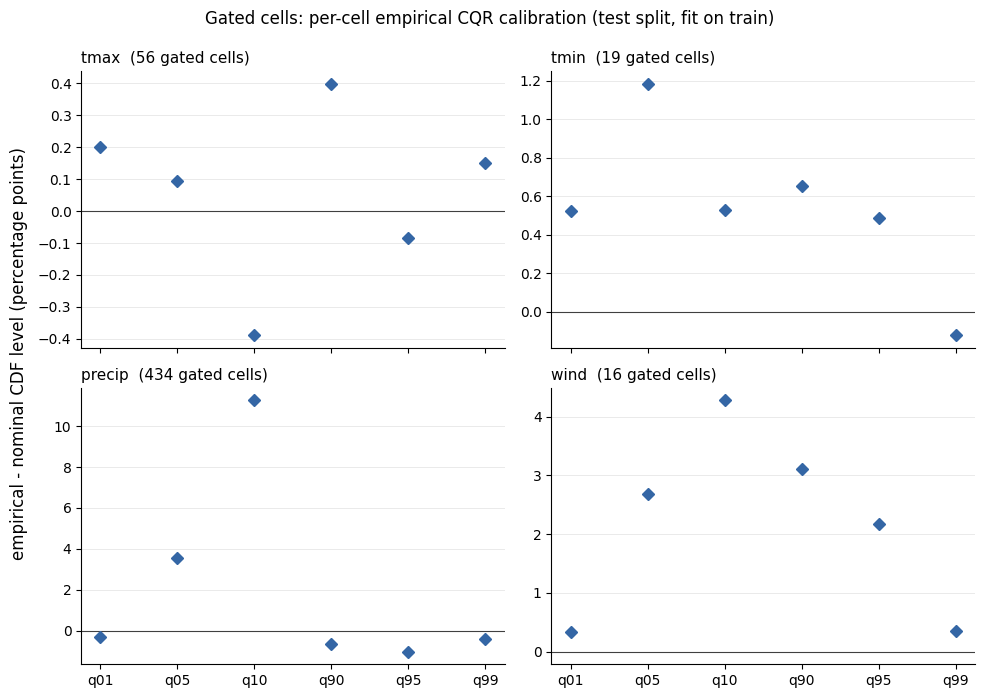

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True)
x_all = np.arange(len(SIDED_LEVELS))
x_labels = [f"q{int(level * 100):02d}" for level in SIDED_LEVELS]
for ax, name in zip(axes.flat, VAR_NAMES):
    cdf = gated_coverage[gated_coverage["var"] == name].set_index("level").empirical_cdf
    ax.axhline(0, color="0.25", lw=0.8)
    ax.plot(x_all, [(cdf[level] - level) * 100 for level in SIDED_LEVELS],
            "D", color=CALIBRATED_COLOR, ms=6)
    ax.set_title(f"{name}  ({gate_counts[name]} gated cells)", loc="left", fontsize=11)
    ax.set_xticks(x_all, x_labels)
    ax.grid(axis="y", color="0.9", lw=0.6)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
fig.supylabel("empirical - nominal CDF level (percentage points)")
fig.suptitle("Gated cells: per-cell empirical CQR calibration"
             " (test split, fit on train)", y=0.99)
fig.tight_layout()
plt.show()

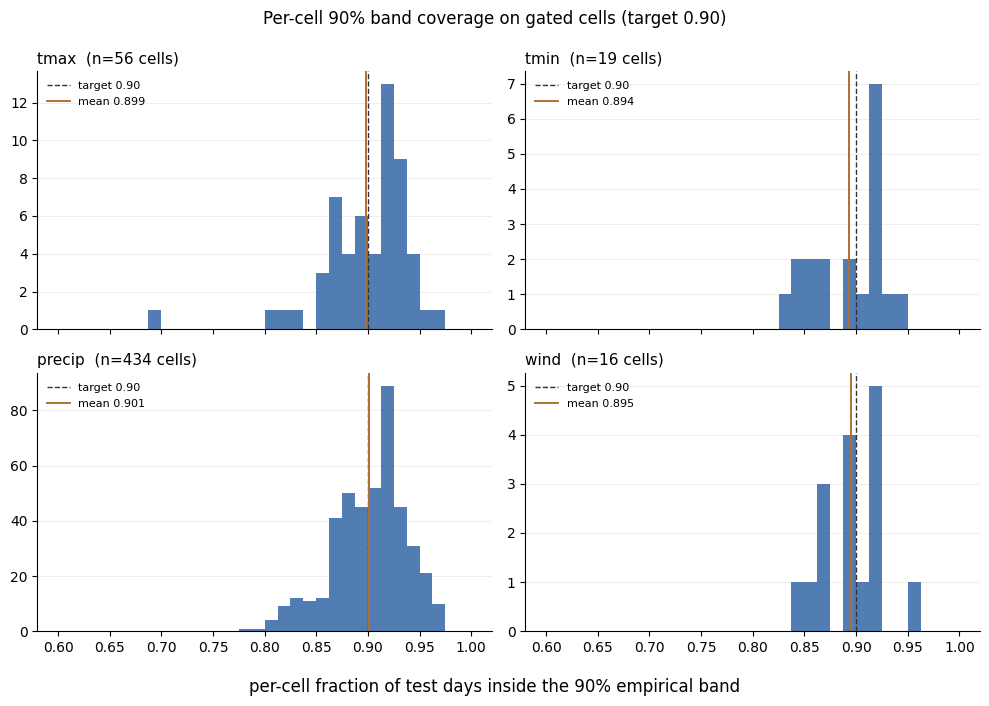

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True)
bins = np.linspace(0.6, 1.0, 33)
for ax, name in zip(axes.flat, VAR_NAMES):
    covers = gated_percell[gated_percell["var"] == name].cover90.to_numpy()
    ax.hist(covers, bins=bins, color=CALIBRATED_COLOR, alpha=0.85)
    ax.axvline(0.90, color="0.2", ls="--", lw=1, label="target 0.90")
    ax.axvline(covers.mean(), color=RAW_COLOR, lw=1.4, label=f"mean {covers.mean():.3f}")
    ax.set_title(f"{name}  (n={len(covers)} cells)", loc="left", fontsize=11)
    ax.legend(frameon=False, fontsize=8)
    ax.grid(axis="y", color="0.92", lw=0.6)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
fig.supxlabel("per-cell fraction of test days inside the 90% empirical band")
fig.suptitle("Per-cell 90% band coverage on gated cells (target 0.90)", y=0.99)
fig.tight_layout()
plt.show()

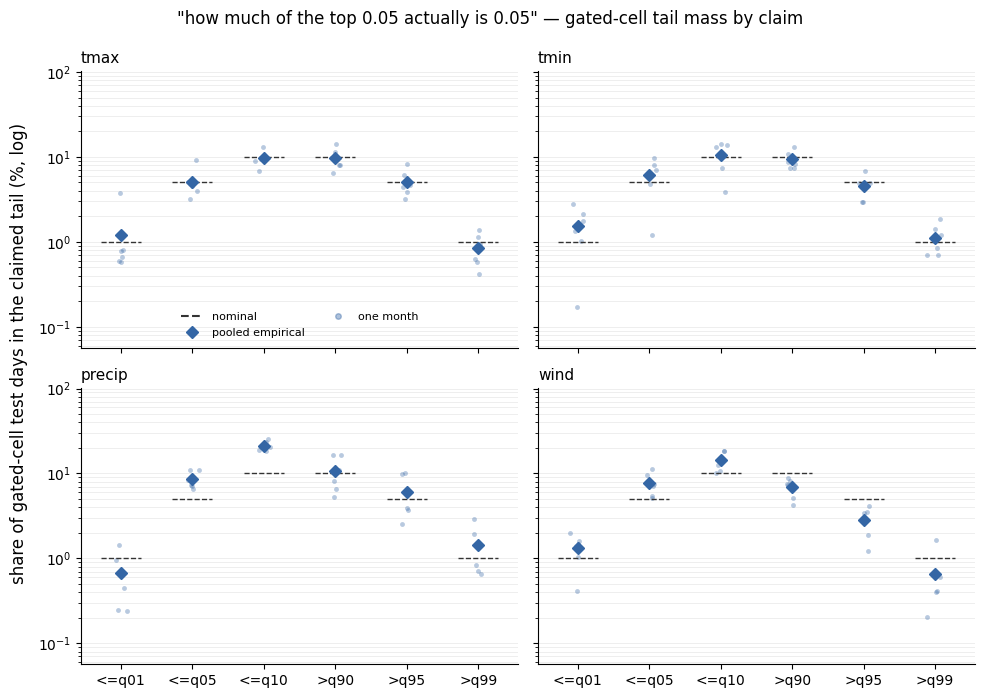

In [9]:
from matplotlib.lines import Line2D

CLAIMS = [(0.01, "<=q01"), (0.05, "<=q05"), (0.10, "<=q10"),
          (0.90, ">q90"), (0.95, ">q95"), (0.99, ">q99")]
nominal_pct = [level * 100 if level < 0.5 else (1 - level) * 100 for level, _ in CLAIMS]

jitter_rng = np.random.default_rng(0)
plotted_pct = []
fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True, sharey=True)
for ax, name in zip(axes.flat, VAR_NAMES):
    aggregate = gated_coverage[gated_coverage["var"] == name].set_index("level").empirical_cdf
    for i, (level, _) in enumerate(CLAIMS):
        months = gated_monthly[(gated_monthly["var"] == name)
                               & (gated_monthly.level == level)].tail_mass.to_numpy()
        month_pct = np.where(months > 0, months, np.nan) * 100
        plotted_pct += [m for m in month_pct if np.isfinite(m)]
        ax.plot(i + jitter_rng.normal(0, 0.05, len(months)), month_pct,
                "o", color=CALIBRATED_COLOR, ms=3.5, alpha=0.35, mec="none")
        ax.hlines(nominal_pct[i], i - 0.28, i + 0.28, color="0.2", lw=1, ls="--")
        cdf = aggregate[level]
        tail = cdf if level < 0.5 else 1 - cdf
        if tail > 1e-9:
            plotted_pct.append(tail * 100)
            ax.plot(i, tail * 100, "D", color=CALIBRATED_COLOR, ms=6)
    ax.set_yscale("log")
    ax.set_title(name, loc="left", fontsize=11)
    ax.set_xticks(range(len(CLAIMS)), [claim for _, claim in CLAIMS])
    ax.grid(axis="y", color="0.92", lw=0.6, which="both")
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
axes[0, 0].set_ylim(min(plotted_pct) / 3, max(plotted_pct) * 4)
fig.supylabel("share of gated-cell test days in the claimed tail (%, log)")
axes[0, 0].legend(handles=[
    Line2D([], [], ls="--", color="0.2", label="nominal"),
    Line2D([], [], marker="D", color=CALIBRATED_COLOR, ls="", label="pooled empirical"),
    Line2D([], [], marker="o", color=CALIBRATED_COLOR, ls="", ms=4, alpha=0.4,
           label="one month")], frameon=False, fontsize=8, loc="lower center", ncol=2)
fig.suptitle('"how much of the top 0.05 actually is 0.05" — gated-cell tail mass'
             " by claim", y=0.99)
fig.tight_layout()
plt.show()

### Conditional coverage — does a constant band survive an extreme forecast?

The per-cell band is a **single constant per cell** — it does not move with the
day's forecast. So the stress test is the same as for the model: slice the test
days by **within-cell forecast extremeness** (rank vs the cell's own training
forecasts) and ask whether the fixed band still lands nominally when the forecast
is extreme for that place. `ratio` = empirical / nominal (1.00 = honest).

Expect **more** conditional drift here than for the model band above: the model's
head at least slides with the forecast value, while a constant band cannot.
Precip's lower forecast bins are empty by construction (dry atom). The money cells
are the **top-forecast regime x upper claims** — a heavy-rain or record-heat day —
where a band built mostly from ordinary days is too narrow.

bin           bottom 1%  1–5%  5–25%  25–75%  75–95%  95–99%  top 1%
var    level                                                        
tmax   0.01        2.04  1.89   2.46    0.86    0.40    0.84    0.55
       0.05        1.02  1.85   1.37    0.99    0.57    0.84    0.33
       0.10        0.61  1.45   1.09    1.02    0.60    1.00    0.60
       0.90        3.57  1.24   0.91    0.90    0.97    1.00    0.93
       0.95        5.10  1.43   0.98    0.92    1.14    0.67    0.33
       0.99        8.16  1.47   0.88    0.84    0.55    0.21    0.00
tmin   0.01        0.00  0.51   2.13    0.69    2.61    3.70    3.92
       0.05        1.13  0.92   1.60    0.77    1.83    1.78    2.35
       0.10        0.57  0.72   1.16    0.80    1.55    1.33    1.76
       0.90        1.51  1.49   1.09    0.98    0.67    0.22    0.00
       0.95        1.89  0.92   0.85    1.11    0.64    0.00    0.00
       0.99        3.77  1.03   0.80    1.25    1.31    0.00    0.00
precip 0.01         NaN   NaN   0.00    0.00    0.16    4.76   20.36
       0.05         NaN   NaN   0.00    0.00    2.23   11.06    7.65
       0.10         NaN   NaN   0.00    0.15    4.16    6.14    4.48
       0.90         NaN   NaN   0.39    0.47    1.53    2.61    4.30
       0.95         NaN   NaN   0.22    0.38    1.68    3.95    6.93
       0.99         NaN   NaN   0.19    0.23    1.52    6.88   18.27
wind   0.01        0.00  0.00   0.50    0.57    2.49    8.39    0.00
       0.05        0.00  0.82   0.93    1.12    2.49    4.52    2.58
       0.10        0.00  0.74   1.12    1.20    2.03    3.03    1.61
       0.90        3.50  1.15   0.78    0.64    0.53    0.71    0.65
       0.95        2.00  0.98   0.66    0.50    0.47    0.65    0.65
       0.99        5.00  1.64   0.17    0.72    0.33    1.94    0.00

smallest bin: n=0 — the 1% rungs in a thin regime are binomial-noisy, read the direction not the digit


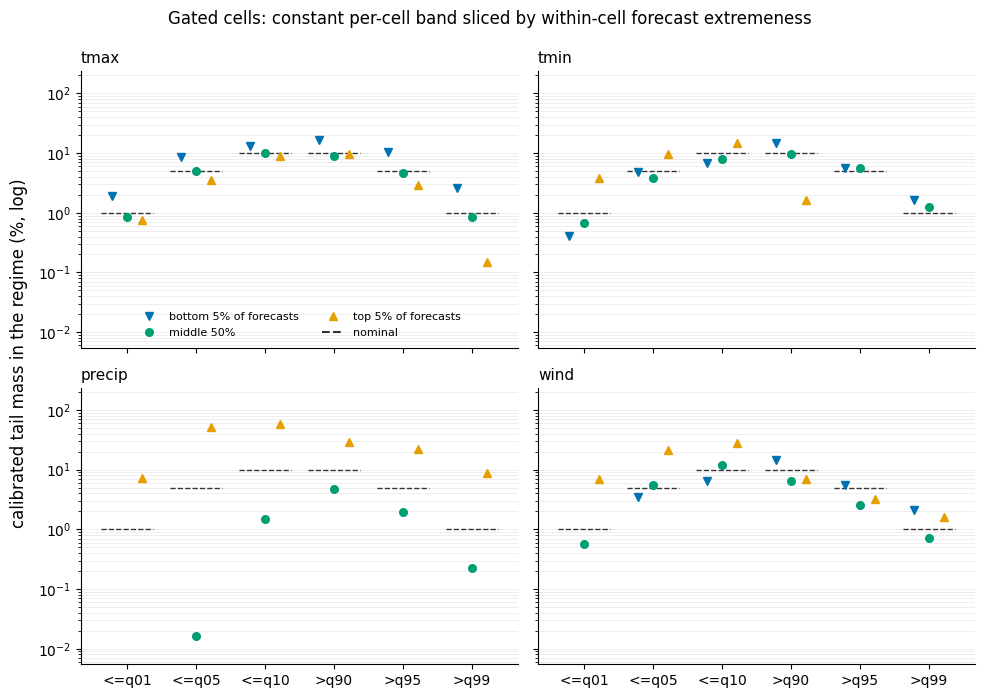

In [10]:
CLAIMS = [(0.01, "<=q01"), (0.05, "<=q05"), (0.10, "<=q10"),
          (0.90, ">q90"), (0.95, ">q95"), (0.99, ">q99")]
nominal_pct = [level * 100 if level < 0.5 else (1 - level) * 100 for level, _ in CLAIMS]

gated_conditional["ratio"] = gated_conditional.tail_mass / [
    level if level < 0.5 else round(1 - level, 6) for level in gated_conditional.level]
gated_conditional_ratio = (gated_conditional.pivot_table(
    index=["var", "level"], columns="bin", values="ratio", observed=False)
    .reindex(index=VAR_NAMES, level=0).reindex(columns=FORECAST_BIN_LABELS))
display(gated_conditional_ratio.round(2))
print(f"smallest bin: n={gated_conditional.n.min():,} — the 1% rungs in a thin"
      " regime are binomial-noisy, read the direction not the digit")

REGIMES = [("bottom 5% of forecasts", ["bottom 1%", "1–5%"], "#0072B2", "v"),
           ("middle 50%", ["25–75%"], "#009E73", "o"),
           ("top 5% of forecasts", ["95–99%", "top 1%"], "#E69F00", "^")]

plotted_pct = []
fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True, sharey=True)
for ax, name in zip(axes.flat, VAR_NAMES):
    for i, (level, _) in enumerate(CLAIMS):
        ax.hlines(nominal_pct[i], i - 0.38, i + 0.38, color="0.2", lw=1, ls="--")
        for offset, (regime, regime_bins, color, marker) in zip((-0.22, 0, 0.22), REGIMES):
            sub = gated_conditional[(gated_conditional["var"] == name)
                                    & (gated_conditional.level == level)
                                    & gated_conditional.bin.isin(regime_bins)
                                    ].dropna(subset=["tail_mass"])
            if not sub.n.sum():
                continue
            mass_pct = (sub.tail_mass * sub.n).sum() / sub.n.sum() * 100
            if mass_pct <= 0:
                continue
            plotted_pct.append(mass_pct)
            ax.plot(i + offset, mass_pct, marker, color=color, ms=5.5)
    ax.set_yscale("log")
    ax.set_title(name, loc="left", fontsize=11)
    ax.set_xticks(range(len(CLAIMS)), [claim for _, claim in CLAIMS])
    ax.grid(axis="y", color="0.92", lw=0.6, which="both")
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
axes[0, 0].set_ylim(min(plotted_pct) / 3, max(plotted_pct) * 4)
fig.supylabel("calibrated tail mass in the regime (%, log)")
axes[0, 0].legend(handles=[
    Line2D([], [], marker=marker, color=color, ls="", ms=5.5, label=regime)
    for regime, _, color, marker in REGIMES]
    + [Line2D([], [], ls="--", color="0.2", label="nominal")],
    frameon=False, fontsize=8, loc="lower center", ncol=2)
fig.suptitle("Gated cells: constant per-cell band sliced by within-cell"
             " forecast extremeness", y=0.99)
fig.tight_layout()
plt.show()

### Gated findings / what to look for

- **Marginally honest, conditionally drifting.** Pooled coverage and per-cell 90%
  band coverage sit on nominal (~0.90), but the constant band over/under-fires on
  extreme-forecast days — precip heavy-rain days blow through the upper band
  (ratio >> 1 at q95/q99), temps drift on their cold/hot extremes. That is the
  price of a forecast-independent band and unavoidable without conditioning.
  Product consequence: keep fuzzy wording bins on the 1% rungs for these cells.
- **`dmid = 0` leaves the point off-centre where the cell is biased.** The median
  residual is nonzero (e.g. wind ~+0.2 m/s: raw under-forecasts, truth usually
  higher), so the raw point is not the band's middle. Intended — the gate rejected
  the median correction; the asymmetric band honestly shows the raw value is
  typically an under/over-shoot.
- **Precip lower tails are tie-dominated** (dry-day atom); judge precip on the wet
  upper tail only, same as the model study.
- **Per-cell thin tails.** Fitting q01/q99 from ~600 residuals is order-stat noisy;
  the rule errs wide (the safe direction). A gated cell with <100 residuals would
  widen further — none do here.
- **Ship constants** are saved to `models/gated_empirical_cqr_qn8727_s0.csv` (per
  cell x level, fit on train+test). Baking these as `dmid=0` empirical rows is the
  gated-band plan (`empirical-bands-for-gated-cells-lucid-parzen.md`); this notebook
  is its validity study — nothing here writes to R2.

## Conditional CQR for gated precip - a band that widens with the forecast

The per-cell band above is **one width for every day**. Precip residuals are
heteroscedastic: near-zero when the forecast is dry, fanning out on heavy-rain
days. So the constant band is far too wide when it is dry (covers ~99%) and far
too narrow on the days that matter (collapses well below the promised level).

The fix is to make the band **conditional on the forecast**. We bin days by
forecast magnitude and fit the empirical residual quantiles *within each bin*,
pooling across the gated precip cells so the heavy bins have enough samples.
The point stays raw (dmid = 0); only the band half-widths change. Fit on
`train`, judged on the held-out `test` half - same protocol as the constant
band, so the two are directly comparable.

In [11]:
# ============================================================================
# Conditional CQR for gated PRECIP: band width tracks the day's forecast.
# Constant per-cell band (cell 11) = one width for every day. Here the residual
# quantiles are fit WITHIN forecast-magnitude bins (pooled across gated precip
# cells so heavy bins have enough samples), giving a band that fans out with the
# forecast. Fit on `train`, judged on `test`.
# ============================================================================
name = "precip"
hcol, bcol = tqd.hres_col(name), f"bias_{name}"
trace = tqd.PRECIP_TRACE_MM
gated = gated_keys_by_var[name]

sub = data[data.key.isin(gated) & data[bcol].notna()]
train = sub[sub.role == "train"]
test = sub[sub.role == "test"]

# --- conditional model: forecast-magnitude bins, residual quantiles pooled ---
train_fc = train[hcol].to_numpy()
train_res = train[bcol].to_numpy()
wet = train_fc[train_fc >= trace]
inner_edges = np.quantile(wet, [0.20, 0.40, 0.60, 0.75, 0.87, 0.95])
inner_edges = np.unique(inner_edges[inner_edges > trace])
FC_EDGES = np.concatenate([[-np.inf, trace], inner_edges, [np.inf]])


def to_fbin(fc):
    return np.clip(np.searchsorted(FC_EDGES, fc, side="right") - 1, 0, len(FC_EDGES) - 2)


train_fc_bin = to_fbin(train_fc)
bin_fit, bin_rows = {}, []
for b in range(len(FC_EDGES) - 1):
    r = train_res[train_fc_bin == b]
    if len(r) == 0:
        r = train_res
    bin_fit[b] = {lvl: per_level_shift(r, lvl) for lvl in SIDED_LEVELS}
    upper = FC_EDGES[b + 1] if np.isfinite(FC_EDGES[b + 1]) else train_fc.max()
    label = ("dry (<%.0fmm)" % trace) if b == 0 else ("%.1f-%.1fmm" % (FC_EDGES[b], upper))
    bin_rows.append(dict(bin=b, forecast=label, n=len(r),
                         fc_med=float(np.median(train_fc[train_fc_bin == b])),
                         width90=bin_fit[b][0.95] - bin_fit[b][0.05],
                         width98=bin_fit[b][0.99] - bin_fit[b][0.01]))
bin_table = pd.DataFrame(bin_rows)

# --- constant per-cell band (the cell-11 baseline), fit on train ------------
const_fit = {}
for key, grp in train.groupby("key", observed=True):
    r = grp[bcol].to_numpy()
    const_fit[key] = {lvl: per_level_shift(r, lvl) for lvl in SIDED_LEVELS}

# --- apply both to the held-out test half -----------------------------------
test = test[test.key.isin(const_fit)]
tk = test.key.astype(object).to_numpy()
th = test[hcol].to_numpy()
ty = test[bcol].to_numpy()
te_era5 = ty + th
tbin = to_fbin(th)
cond_heads = {lvl: np.array([bin_fit[b][lvl] for b in tbin]) for lvl in SIDED_LEVELS}
const_heads = {lvl: np.array([const_fit[k][lvl] for k in tk]) for lvl in SIDED_LEVELS}

# within-cell forecast percentile (regime axis, vs each cell's own train forecasts)
sorted_tr_fc = {k: np.sort(v.to_numpy()) for k, v in train.groupby("key", observed=True)[hcol]}
pcp_pct = np.full(len(test), np.nan)
for k, pos in test.groupby("key", observed=True).indices.items():
    ref = sorted_tr_fc.get(k)
    if ref is not None and len(ref):
        pcp_pct[pos] = np.searchsorted(ref, th[pos], side="right") / len(ref)

if CELL_LIMIT is None:
    cond_csv = tqd.MODELS / f"gated_precip_conditional_cqr_{MODEL_TAG}.csv"
    pd.DataFrame([{"bin": b, "lo": float(FC_EDGES[b]), "hi": float(FC_EDGES[b + 1]),
                   "level": lvl, "shift": bin_fit[b][lvl]}
                  for b in range(len(FC_EDGES) - 1) for lvl in SIDED_LEVELS]
                 ).to_csv(cond_csv, index=False)
    print("saved", cond_csv.name)

print("forecast-magnitude bins (pooled across %d gated precip cells):" % len(const_fit))
print(bin_table.round(2).to_string(index=False))
for lo, hi, tag in [(0.05, 0.95, "90%"), (0.01, 0.99, "98%")]:
    c = np.mean((ty >= const_heads[lo]) & (ty <= const_heads[hi]))
    d = np.mean((ty >= cond_heads[lo]) & (ty <= cond_heads[hi]))
    print(f"marginal {tag} band  constant={c:.3f}  conditional={d:.3f}")

saved gated_precip_conditional_cqr_qn8727_s0.csv
forecast-magnitude bins (pooled across 434 gated precip cells):
 bin     forecast      n  fc_med  width90  width98
   0   dry (<1mm) 119859     0.0     2.01     6.28
   1    1.0-2.1mm  13120     1.4     9.95    18.37
   2    2.1-4.1mm  12979     2.9    14.68    26.73
   3    4.1-7.9mm  13283     5.7    19.88    34.45
   4   7.9-13.0mm  10005    10.1    24.96    42.71
   5  13.0-20.8mm   7897    16.1    33.02    58.65
   6  20.8-34.0mm   5307    25.4    43.98    76.65
   7 34.0-728.9mm   3302    45.4    79.50   140.58
marginal 90% band  constant=0.901  conditional=0.938
marginal 98% band  constant=0.979  conditional=0.988


In [12]:
# coverage by within-cell forecast regime: constant band vs conditional band
reg_edges = [0, 0.60, 0.80, 0.90, 0.95, 0.99, 1.0001]
reg_labels = ["dry / <p60", "p60-80", "p80-90", "p90-95", "p95-99", "top 1%"]
regime = pd.cut(pcp_pct, reg_edges, labels=reg_labels, include_lowest=True, right=False)
rows = []
for lab in reg_labels:
    m = np.asarray(regime == lab)
    if m.sum() == 0:
        continue
    yy = ty[m]
    rows.append(dict(
        regime=lab, n=int(m.sum()), fc_mm=round(float(np.median(th[m])), 1),
        const_cover90=float(np.mean((yy >= const_heads[0.05][m]) & (yy <= const_heads[0.95][m]))),
        cond_cover90=float(np.mean((yy >= cond_heads[0.05][m]) & (yy <= cond_heads[0.95][m]))),
        const_cover98=float(np.mean((yy >= const_heads[0.01][m]) & (yy <= const_heads[0.99][m]))),
        cond_cover98=float(np.mean((yy >= cond_heads[0.01][m]) & (yy <= cond_heads[0.99][m]))),
    ))
regime_compare = pd.DataFrame(rows)
display(regime_compare.round(3))

,regime,n,fc_mm,const_cover90,cond_cover90,const_cover98,cond_cover98
0,dry / <p60,18110,0.0,0.989,0.928,0.999,0.985
1,p60-80,33265,0.0,0.970,0.949,0.996,0.991
2,p80-90,14812,0.0,0.881,0.939,0.988,0.989
3,p90-95,6654,5.5,0.725,0.927,0.957,0.986
4,p95-99,5481,13.2,0.597,0.934,0.884,0.986
5,top 1%,1100,43.2,0.271,0.874,0.615,0.977


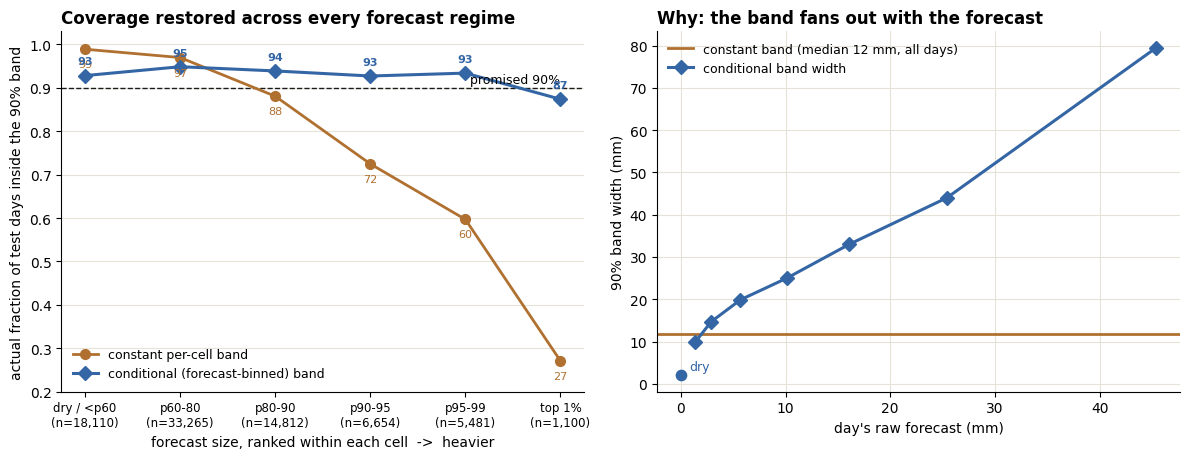

In [13]:
# ===== Fig 1: coverage restored (left) + why the band fans out (right) =======
CONST_C, COND_C, NOMINAL, GRID = RAW_COLOR, CALIBRATED_COLOR, "#1a1a1a", "#e6e2d8"
fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 4.7))

xx = np.arange(len(regime_compare))
axL.axhline(0.90, color=NOMINAL, ls="--", lw=1)
axL.text(xx[-1], 0.905, "promised 90%", ha="right", va="bottom", fontsize=9)
axL.plot(xx, regime_compare.const_cover90, "-o", color=CONST_C, lw=2, ms=7,
         label="constant per-cell band")
axL.plot(xx, regime_compare.cond_cover90, "-D", color=COND_C, lw=2.2, ms=7,
         label="conditional (forecast-binned) band")
for i, rr in regime_compare.iterrows():
    axL.annotate(f"{rr.const_cover90*100:.0f}", (i, rr.const_cover90), textcoords="offset points",
                 xytext=(0, -13), ha="center", fontsize=8, color=CONST_C)
    axL.annotate(f"{rr.cond_cover90*100:.0f}", (i, rr.cond_cover90), textcoords="offset points",
                 xytext=(0, 8), ha="center", fontsize=8, color=COND_C, weight="bold")
axL.set_xticks(xx, [f"{l}\n(n={n:,})" for l, n in zip(regime_compare.regime, regime_compare.n)],
               fontsize=8.5)
axL.set_ylim(0.2, 1.03)
axL.set_ylabel("actual fraction of test days inside the 90% band")
axL.set_xlabel("forecast size, ranked within each cell  ->  heavier")
axL.set_title("Coverage restored across every forecast regime", loc="left",
              fontsize=12, weight="bold")
axL.grid(axis="y", color=GRID, lw=0.8)
axL.set_axisbelow(True)
for s in ("top", "right"):
    axL.spines[s].set_visible(False)
axL.legend(frameon=False, fontsize=9, loc="lower left")

const_width_med = float(np.median([const_fit[k][0.95] - const_fit[k][0.05] for k in const_fit]))
axR.axhline(const_width_med, color=CONST_C, lw=2,
            label=f"constant band (median {const_width_med:.0f} mm, all days)")
wet_bins = bin_table[bin_table.bin > 0]
axR.plot(wet_bins.fc_med, wet_bins.width90, "-D", color=COND_C, lw=2.2, ms=7,
         label="conditional band width")
axR.scatter([bin_table.fc_med.iloc[0]], [bin_table.width90.iloc[0]], color=COND_C, s=55, zorder=3)
axR.annotate("dry", (bin_table.fc_med.iloc[0], bin_table.width90.iloc[0]),
             textcoords="offset points", xytext=(6, 4), fontsize=9, color=COND_C)
axR.set_xlabel("day's raw forecast (mm)")
axR.set_ylabel("90% band width (mm)")
axR.set_title("Why: the band fans out with the forecast", loc="left", fontsize=12, weight="bold")
axR.grid(color=GRID, lw=0.8)
axR.set_axisbelow(True)
for s in ("top", "right"):
    axR.spines[s].set_visible(False)
axR.legend(frameon=False, fontsize=9, loc="upper left")
fig.tight_layout()
plt.show()

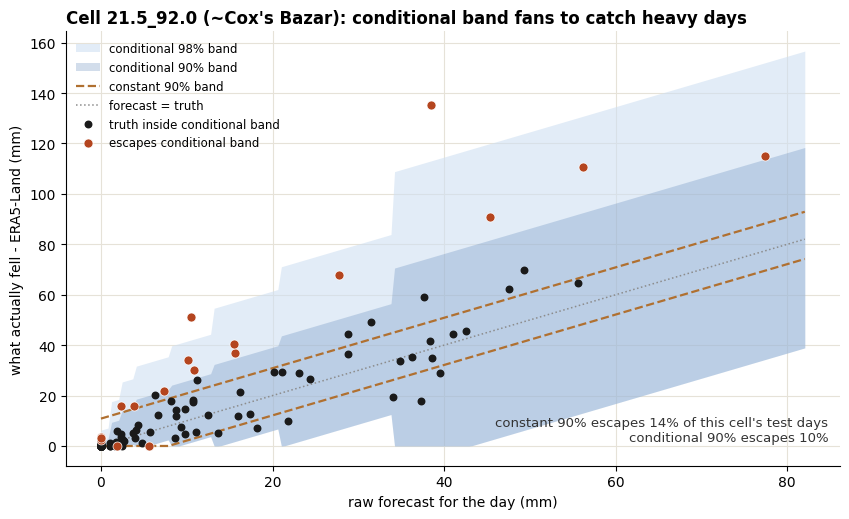

In [14]:
# ===== Fig 2: one heavy cell - constant band vs fanning conditional band =====
ESCAPE = "#B4451F"
CELL = "21.5_92.0"   # ~Cox's Bazar, the worst-damage gated precip cell
cmask = tk == CELL
cf, cera5 = th[cmask], te_era5[cmask]
grid = np.linspace(0, cf.max() * 1.06, 200)
gbin = to_fbin(grid)
cond_lo = np.clip(grid + np.array([bin_fit[b][0.05] for b in gbin]), 0, None)
cond_hi = grid + np.array([bin_fit[b][0.95] for b in gbin])
cond_hi98 = grid + np.array([bin_fit[b][0.99] for b in gbin])
const_lo = np.clip(grid + const_fit[CELL][0.05], 0, None)
const_hi = grid + const_fit[CELL][0.95]

cbin = to_fbin(cf)
cell_cond_lo = np.clip(cf + np.array([bin_fit[b][0.05] for b in cbin]), 0, None)
cell_cond_hi = cf + np.array([bin_fit[b][0.95] for b in cbin])
inside_cond = (cera5 >= cell_cond_lo) & (cera5 <= cell_cond_hi)
inside_const = (cera5 >= np.clip(cf + const_fit[CELL][0.05], 0, None)) & (cera5 <= cf + const_fit[CELL][0.95])

fig, ax = plt.subplots(figsize=(8.6, 5.3))
ax.fill_between(grid, cond_lo, cond_hi98, color="#cfe0f2", alpha=0.6, lw=0, label="conditional 98% band")
ax.fill_between(grid, cond_lo, cond_hi, color=COND_C, alpha=0.22, lw=0, label="conditional 90% band")
ax.plot(grid, const_lo, color=CONST_C, lw=1.6, ls="--")
ax.plot(grid, const_hi, color=CONST_C, lw=1.6, ls="--", label="constant 90% band")
ax.plot(grid, grid, color="0.55", ls=":", lw=1.1, label="forecast = truth")
ax.scatter(cf[inside_cond], cera5[inside_cond], s=22, color="#1a1a1a", zorder=3,
           label="truth inside conditional band")
ax.scatter(cf[~inside_cond], cera5[~inside_cond], s=42, color=ESCAPE, ec="white", lw=0.5, zorder=4,
           label="escapes conditional band")
ax.set_xlabel("raw forecast for the day (mm)")
ax.set_ylabel("what actually fell - ERA5-Land (mm)")
ax.set_title(f"Cell {CELL} (~Cox's Bazar): conditional band fans to catch heavy days",
             loc="left", fontsize=12, weight="bold")
ax.text(0.985, 0.05,
        f"constant 90% escapes {(~inside_const).mean()*100:.0f}% of this cell's test days\n"
        f"conditional 90% escapes {(~inside_cond).mean()*100:.0f}%",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=9.5, color="#333")
ax.grid(color=GRID, lw=0.8)
ax.set_axisbelow(True)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
ax.legend(frameon=False, fontsize=8.5, loc="upper left")
fig.tight_layout()
plt.show()

### All 6 directional rungs, not just the two bands

The bands above are two-sided *pairs* of the fit, but the model is 6 one-sided
quantiles per forecast bin (q01/q05/q10/q90/q95/q99), and they are asymmetric -
heavy forecasts bust downward more than up. Here is the per-rung one-sided
reliability by forecast regime, the same view the model half reports in the
CLAIMS table: each head's empirical CDF should sit at its nominal level in every
regime.

Read precip on the **wet-tail rungs (q90/q95/q99)**. The lower rungs
(q01/q05/q10) are not meaningful here: 60%+ of days are exactly 0 mm, a point
mass at bias = 0, so `P(bias <= a near-zero shift)` is dominated by ties rather
than the shift - the same dry-atom caveat as the gated findings above. On the
wet tail the conditional band holds its nominal level across every regime; the
constant band's rungs drift badly as the forecast grows.

target = the rung's own level (q05 -> 0.05, q95 -> 0.95, ...)
lower rungs (q01/q05/q10) sit in the dry-day zero atom -> read the wet tail

CONDITIONAL band  P(y <= head):


regime,dry / <p60,p60-80,p80-90,p90-95,p95-99,top 1%
level,,,,,,
0.01,0.681,0.691,0.505,0.420,0.352,0.015
0.05,0.687,0.699,0.523,0.440,0.368,0.049
0.10,0.696,0.711,0.541,0.460,0.391,0.086
0.90,0.868,0.914,0.914,0.907,0.906,0.829
0.95,0.934,0.958,0.959,0.952,0.954,0.923
0.99,0.986,0.992,0.991,0.991,0.991,0.993


CONSTANT band  P(y <= head):


regime,dry / <p60,p60-80,p80-90,p90-95,p95-99,top 1%
level,,,,,,
0.01,0.000,0.000,0.000,0.007,0.048,0.204
0.05,0.000,0.001,0.047,0.390,0.553,0.383
0.10,0.001,0.064,0.447,0.642,0.614,0.448
0.90,0.970,0.930,0.843,0.796,0.739,0.570
0.95,0.989,0.970,0.918,0.861,0.803,0.654
0.99,0.999,0.996,0.988,0.964,0.931,0.817


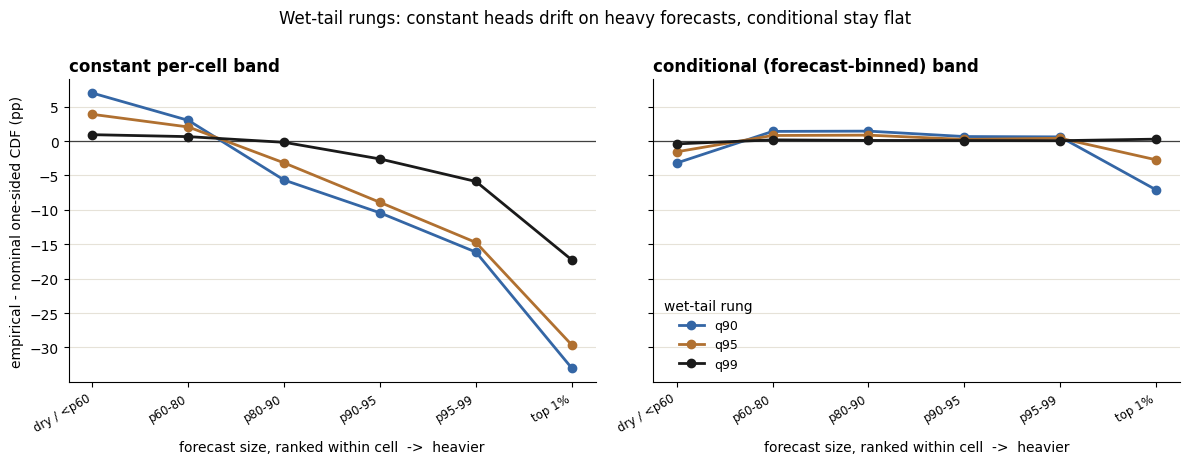

In [15]:
# one-sided empirical CDF at each of the 6 rungs, by forecast regime
rung_rows = []
for lab in reg_labels:
    m = np.asarray(regime == lab)
    if m.sum() == 0:
        continue
    for lvl in SIDED_LEVELS:
        rung_rows.append(dict(regime=lab, level=lvl,
                              cond=float(np.mean(ty[m] <= cond_heads[lvl][m])),
                              const=float(np.mean(ty[m] <= const_heads[lvl][m]))))
rung = pd.DataFrame(rung_rows)
cond_tab = rung.pivot(index="level", columns="regime", values="cond").reindex(columns=reg_labels)
const_tab = rung.pivot(index="level", columns="regime", values="const").reindex(columns=reg_labels)
print("target = the rung's own level (q05 -> 0.05, q95 -> 0.95, ...)")
print("lower rungs (q01/q05/q10) sit in the dry-day zero atom -> read the wet tail")
print("\nCONDITIONAL band  P(y <= head):")
display(cond_tab.round(3))
print("CONSTANT band  P(y <= head):")
display(const_tab.round(3))

# deviation view for the meaningful wet-tail rungs, const vs conditional
wet_rungs = [0.90, 0.95, 0.99]
rung_colors = {0.90: "#3466A5", 0.95: "#B07030", 0.99: "#1a1a1a"}
xx = np.arange(len(reg_labels))
fig, (a0, a1) = plt.subplots(1, 2, figsize=(12, 4.6), sharey=True)
for ax, heads, title in [(a0, const_heads, "constant per-cell band"),
                         (a1, cond_heads, "conditional (forecast-binned) band")]:
    ax.axhline(0, color="0.25", lw=0.9)
    for lvl in wet_rungs:
        dev = [(np.mean(ty[np.asarray(regime == lab)] <= heads[lvl][np.asarray(regime == lab)]) - lvl) * 100
               for lab in reg_labels]
        ax.plot(xx, dev, "-o", color=rung_colors[lvl], ms=6, lw=2, label=f"q{int(lvl * 100):02d}")
    ax.set_xticks(xx, reg_labels, rotation=30, ha="right", fontsize=8.5)
    ax.set_title(title, loc="left", fontsize=12, weight="bold")
    ax.set_xlabel("forecast size, ranked within cell  ->  heavier")
    ax.grid(axis="y", color=GRID, lw=0.8)
    ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
a0.set_ylabel("empirical - nominal one-sided CDF (pp)")
a1.legend(frameon=False, fontsize=9, loc="lower left", title="wet-tail rung")
fig.suptitle("Wet-tail rungs: constant heads drift on heavy forecasts, conditional stay flat",
             y=1.0, fontsize=12)
fig.tight_layout()
plt.show()

### What the conditional band buys

- **Coverage holds across regimes** (left figure): the constant band's 90%
  coverage slides from ~99% on dry days down toward the ~30s on the heaviest
  forecasts; the forecast-binned band stays near the promised 90% everywhere.
- **Width tracks the forecast** (right figure): flat for the constant band,
  rising from the dry bin to tens of mm on heavy-forecast bins.
- **Cox's Bazar**: the fanning band catches heavy-day truth the constant band
  lets escape.

Caveat: the heavy-forecast bins are **pooled across gated precip cells** (a
single cell has too few heavy days to fit its own q99). That trades per-cell
climatology for stable tail widths - acceptable because the forecast magnitude
already carries most of the day's expected rain. Study only; nothing shipped to
R2 yet.